# The Product Pricer Continued

- A **copy** of the Week 6 Day 2 Lite version, modified to apply only to the **'Appliances'** category.
- Using 25_000 for training, and 2_500 for testing.
- Change lite to lite1.
- A model that can estimate how much something costs, from its description.

## Data Curation Part 2

Today we'll extend our dataset to a greater coverage, and craft it into an excellent dataset for training.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

## The Lite dataset

This notebook is an alternative to `day2.lite.ipynb` that creates a smaller dataset for Home Appliances only, to keep training fast and costs low. You may need to update names of future notebooks to reflect that you have built the **"lite1"** dataset not the full dataset.

In [1]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict

import sys
sys.path.append('../week6') 

from items import Item
from loaders import ItemLoader

import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

In [2]:
# environment

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
%matplotlib inline

## The ItemLoader code

Look in loaders.py - there's some useful code to make life easier for us

## Now to SCALE UP

Let's look at all datasets of all the items that you might find in a large home retail store - electrical, electronic, office and related, but not clothes / beauty / books.

In [5]:
dataset_names = [
    # "Tools_and_Home_Improvement", 
    # "Automotive",    
    # "Electronics",
    # "Office_Products",
    # "Cell_Phones_and_Accessories",
    # # "Toys_and_Games",
    # "Software",
    # "Health_and_Personal_Care",
    "Appliances",
    # "Musical_Instruments",
]

In [6]:
# Enhanced version to keep the datasets and chucks into disk
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load(6))

🔍 Loading dataset: Appliances
✅ Loading from cache: cache\Appliances_dataset


100%|████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:08<00:00, 11.70it/s]


✅ Completed Appliances with 28,625 datapoints in 0.2 mins


In [7]:
print(f"A grand total of {len(items):,} items")

A grand total of 28,625 items


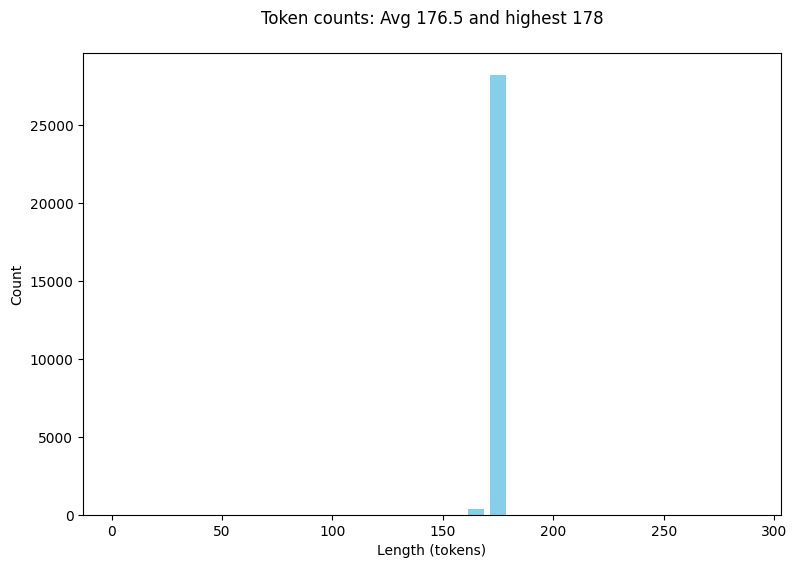

In [8]:
# Plot the distribution of token counts again

tokens = [item.token_count for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="skyblue", bins=range(0, 300, 10))
plt.show()

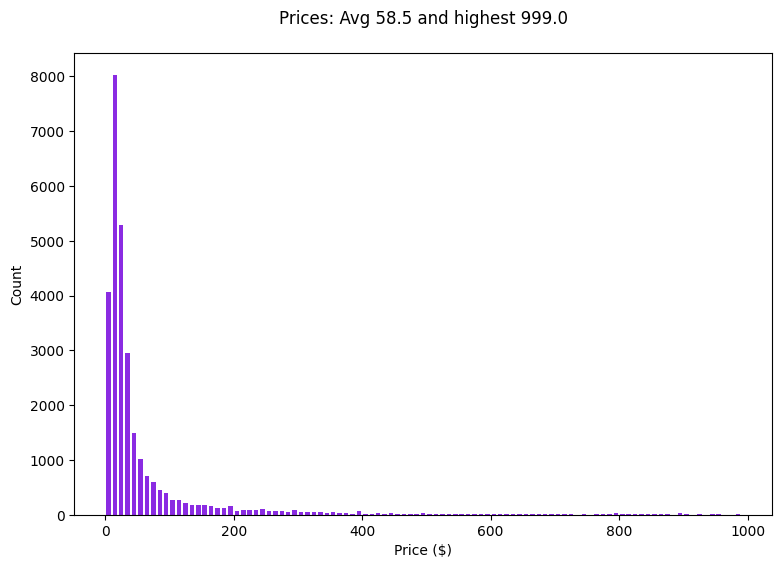

In [9]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(9, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

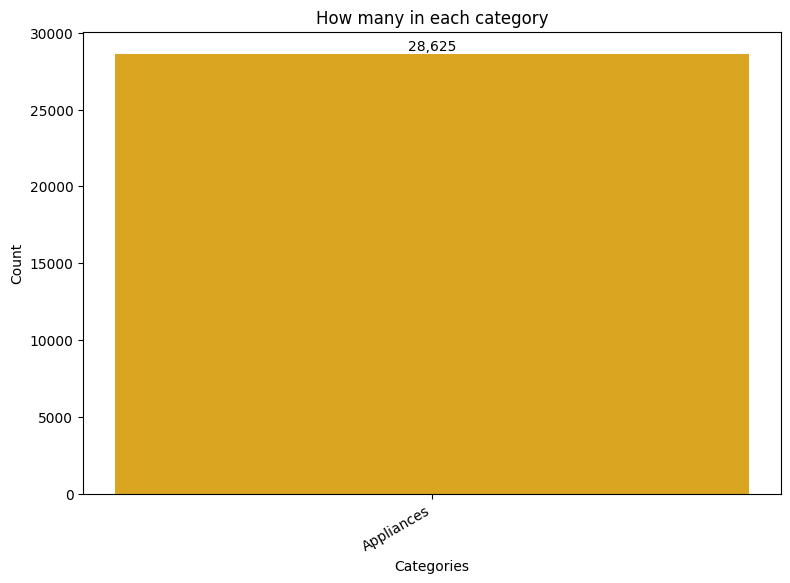

In [10]:
category_counts = Counter()
for item in items:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

# Objective

Craft a dataset which is more balanced in terms of prices. Less heavily scewed to cheap items, with an average that's higher than $60. Try to balance out the categories - fewer Automotive items.

In [11]:
# Create a dict with a key of each price from $1 to $999
# And in the value, put a list of items with that price (to nearest round number)

slots = defaultdict(list)
for item in items:
    slots[round(item.price)].append(item)

In [12]:
# Create a dataset called "sample" which tries to more evenly take from the range of prices
# And gives more weight to items from categories other than Automotive
# Set random seed for reproducibility

np.random.seed(42)
random.seed(42)
sample = []
for i in range(1, 1000):
    slot = slots[i]
    if i>=240:
        sample.extend(slot)
    elif len(slot) <= 1200:
        sample.extend(slot)
    else:

        category_weights = {
            'Automotive': 1
            # 'Musical_Instruments': 6.5,
            # 'Office_Products': 6.25,
            # 'Cell_Phones_and_Accessories': 3.5
        }
        
        weights = np.array([category_weights.get(item.category, 5) for item in slot])        
        # weights = np.array([1 if item.category in ('Musical_Instruments', 'Office_Products') else 6 for item in slot])
        weights = weights / np.sum(weights)
        selected_indices = np.random.choice(len(slot), size=1200, replace=False, p=weights)
        selected = [slot[i] for i in selected_indices]
        sample.extend(selected)

print(f"There are {len(sample):,} items in the sample")

There are 28,544 items in the sample


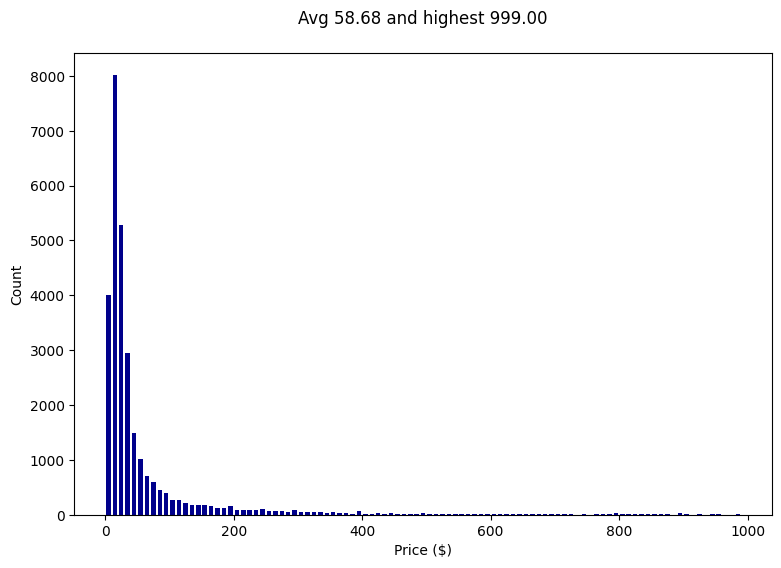

In [13]:
# Plot the distribution of prices in sample

prices = [float(item.price) for item in sample]
plt.figure(figsize=(9, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

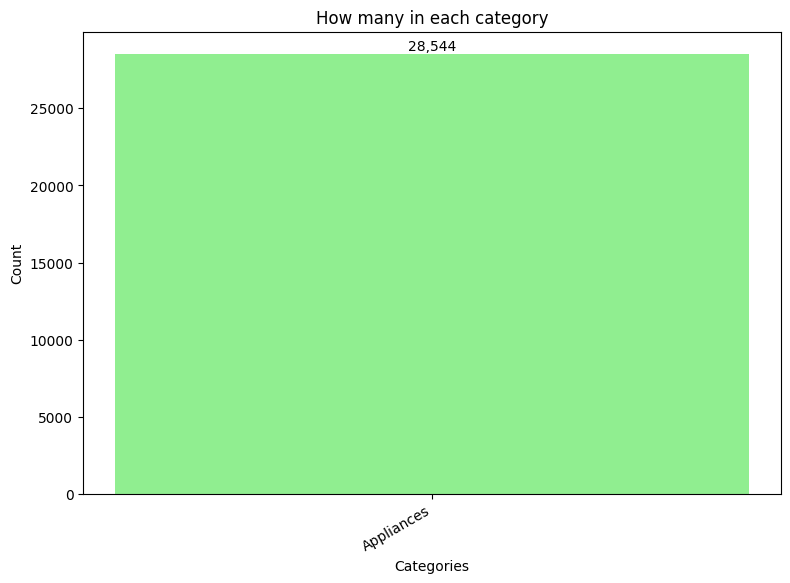

In [14]:
# OK, we did well in terms of raising the average price and having a smooth-ish population of prices
# Let's see the categories

category_counts = Counter()
for item in sample:
    category_counts[item.category]+=1

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Create bar chart
plt.figure(figsize=(9, 6))
plt.bar(categories, counts, color="lightgreen")

# Customize the chart
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

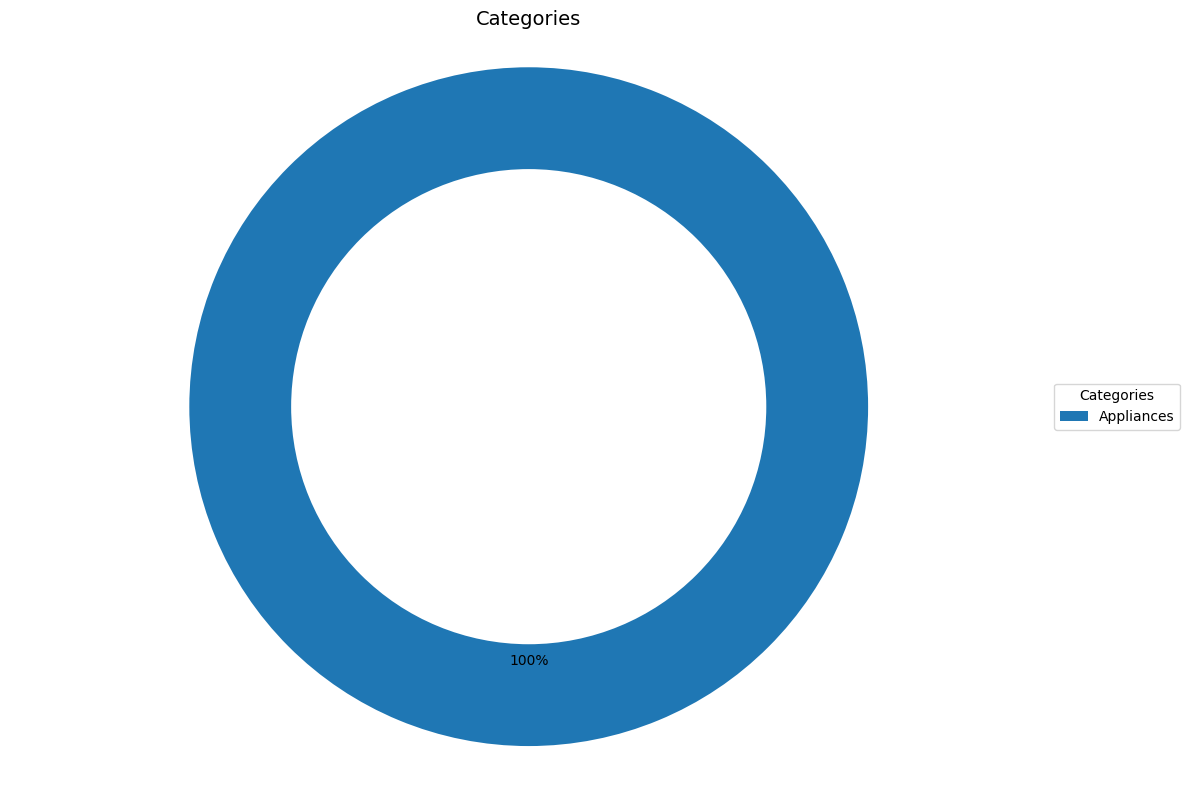

In [15]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 8))

# Draw pie chart with minimal inline labels
wedges, texts, autotexts = plt.pie(
    counts,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)

# Add a circle to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add title
plt.title('Categories', fontsize=14)

# Add legend to the right
plt.legend(wedges, categories, title="Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Ensure pie is circular and layout fits
plt.axis('equal')
plt.tight_layout()
plt.show()


# Dataset Curated!

We've crafted an excellent dataset.

Let's do some final checks

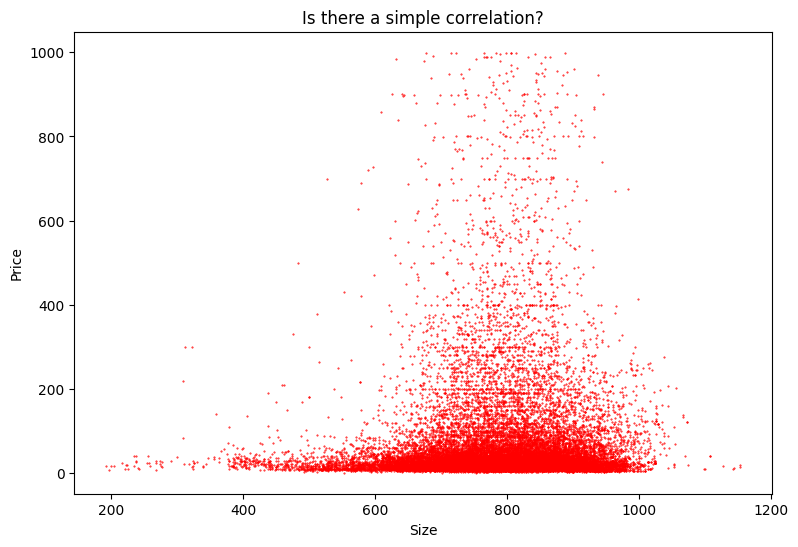

In [16]:
# How does the price vary with the character count of the prompt?

sample = items

sizes = [len(item.prompt) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(9, 6))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation?')

# Display the plot
plt.show()

In [17]:
def report(item):
    prompt = item.prompt
    tokens = Item.tokenizer.encode(item.prompt)
    print(f"Prompt: \n{prompt}")

    last_tokens = tokens[-10:]
    print(f"\nLast 10 tokens: {last_tokens}")
    print(f"Item tokenizer decode last 10 tokens: {Item.tokenizer.batch_decode(last_tokens)}")

In [18]:
report(sample[2000])

Prompt: 
How much does this cost to the nearest dollar?

Replacement for Whirlpool Refrigerator Water Filter - Compatible with Whirlpool Fridge Water Filter Cartridge
This is a Denali Pure Brand replacement part, NOT an OEM product. All mentions of brand names or model descriptions are made strictly to illustrate compatibility. All brand names and logos are registered trademarks of their respective owners. This product is not affiliated with any OEM brands and is not covered under any warranties offered by the original manufacturers. Any warranties for this product are offered solely by Denali Pure. Replacement for Filter Manufacturer Upstart Battery, model number Rank Tools & Home Improvement In-Refrigerator Water Filters 5535, Is Discontinued No, Available May 27, 2015, Duration 6 \tmonths, External Testing Certification ANSI, NSF, WQA, Brand Upstart

Price is $13.00

Last 10 tokens: [16835, 3216, 2527, 271, 7117, 374, 400, 1032, 13, 410]
Item tokenizer decode last 10 tokens: [' Bran

In [19]:
report(sample[15000])

Prompt: 
How much does this cost to the nearest dollar?

BlueStars Ultra Durable Refrigerator Water Inlet Valve DIRECT Replacement for OEM Part Exact Fit for LG Refrigerators - Replaces
✅ EXCELLENT WATER SUPPLIER Refrigerator Water Inlet Valve supplies water to the refrigerator ice maker and water dispenser. It fixes the following symptoms Leaking | Not dispensing water ✅ PERFECT MATCH replaces part numbers etc. It is made exactly fit for most top name brands like LG & Kenmore refrigerators. Feel free to contact us to check the model compatibility. We will be happy to assist you ✅ STURDY MATERIALS Refrigerator Water Inlet Valve is made of sturdy plastic construction with metal brackets, which avoid breaking and leaking during installation and use process. It is a part that meets or exceeds OEM manufacturing requirements. is perfect for your

Price is $27.00

Last 10 tokens: [4832, 369, 701, 271, 7117, 374, 400, 1544, 13, 410]
Item tokenizer decode last 10 tokens: [' perfect', ' for', '

## Observation

An interesting thing about the Llama tokenizer is that every number from 1 to 999 gets mapped to 1 token, much as we saw with gpt-4o. The same is not true of qwen2, gemma and phi3, which all map individual digits to tokens. This does turn out to be a bit useful for our project, although it's not an essential requirement.

# Finally

It's time to break down our data into a training, test and validation dataset.

It's typical to use 5%-10% of your data for testing purposes, but actually we have far more than we need at this point. We'll take 25,000 points for training, and we'll reserve 2,000 for testing, although we won't use all of them.


In [20]:
## Ramdon Sample => takes first 100_000 for training and next 3_000 for testing

random.seed(42)
random.shuffle(sample)

## Revise here ...
train = sample[:25_000]
test = sample[25_000:27_500]
print(f"Divided into a training set of {len(train):,} items and test set of {len(test):,} items")

Divided into a training set of 25,000 items and test set of 2,500 items


In [21]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

and Replacement Range Cooktop Drip Pans fit GE, Hotpoint - Two 6 Inch and Two 8 Inch Pans (4 pieces)
Contents 2 x (6 inches) and 2 x (8 inches) bowls, 4 drip bowls total Compatibility This replacement kit works with GE, Hotpoint, Moffat, Monogram (GE), Profile (GE), RCA (GE), and Roper models prior to 1996. replaces 65975, replaces and 65974, 770169 Premium quality Drip bowls are made of durable high-quality material. It features a chrome finish, well-tested by the manufacturer. Durable, stick-free, easy to clean, and dishwasher safe. Ensure long-lasting and effective performance Easy to install Shut off electrical power, tilt the coil

Price is $12.00


In [22]:
print(test[1].test_prompt())
# print(len(test))

How much does this cost to the nearest dollar?

TUAIC Refrigerator Door Light Switch 2 Feet for GE Whirlpool, Maytag, Admiral, Amana, Crosley, Jenn-Air, Kenmore, KitchenAid, Magic Chef
Production Name TUAIC Refrigerator Door Light Switch 2 Feet. Rated Voltage AC, Rated Current 2.5A 125V, Work Temperature Control Type NC(normally close, most refrigerator control type),Connect Pin Size Universal and compatible design, replace for most Whirlpool, Maytag,Admiral, Amana, Crosley, Jenn-Air, Kenmore, KitchenAid, Magic Chef refrigerators' door light switch. Production Name TUAIC Refrigerator Door Light Switch 2 Feet. Rated Voltage AC, Rated Current 2.5A 125

Price is $


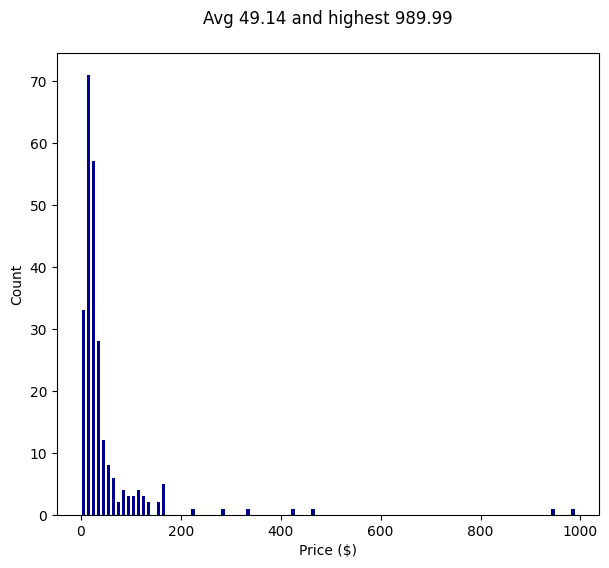

In [23]:
# Plot the distribution of prices in the first 250 test points

prices = [float(item.price) for item in test[:250]]
plt.figure(figsize=(7, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

## Todos for you:

- Investigate the dataset more!
- Confirm that the tokenizer tokenizes all 3 digit prices into 1 token

In [24]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_prices = ["100", "249", "999"]
tokenized_prices = {price: tokenizer.tokenize(price) for price in sample_prices}
print(tokenized_prices)


{'100': ['100'], '249': ['249'], '999': ['999']}


### Investigate the dataset more!

In [25]:
from datasets import load_dataset, get_dataset_config_names
configs = get_dataset_config_names("McAuley-Lab/Amazon-Reviews-2023")
print(configs)

['raw_meta_All_Beauty', 'raw_meta_Toys_and_Games', 'raw_meta_Cell_Phones_and_Accessories', 'raw_meta_Industrial_and_Scientific', 'raw_meta_Gift_Cards', 'raw_meta_Musical_Instruments', 'raw_meta_Electronics', 'raw_meta_Handmade_Products', 'raw_meta_Arts_Crafts_and_Sewing', 'raw_meta_Baby_Products', 'raw_meta_Health_and_Household', 'raw_meta_Office_Products', 'raw_meta_Digital_Music', 'raw_meta_Grocery_and_Gourmet_Food', 'raw_meta_Sports_and_Outdoors', 'raw_meta_Home_and_Kitchen', 'raw_meta_Subscription_Boxes', 'raw_meta_Tools_and_Home_Improvement', 'raw_meta_Pet_Supplies', 'raw_meta_Video_Games', 'raw_meta_Kindle_Store', 'raw_meta_Clothing_Shoes_and_Jewelry', 'raw_meta_Patio_Lawn_and_Garden', 'raw_meta_Unknown', 'raw_meta_Books', 'raw_meta_Automotive', 'raw_meta_CDs_and_Vinyl', 'raw_meta_Beauty_and_Personal_Care', 'raw_meta_Amazon_Fashion', 'raw_meta_Magazine_Subscriptions', 'raw_meta_Software', 'raw_meta_Health_and_Personal_Care', 'raw_meta_Appliances', 'raw_meta_Movies_and_TV', 'raw_r

In [26]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="5core_timestamp_w_his_Musical_Instruments", split="train")


In [27]:
print(dataset[0])
print(dataset.features)
print(f"Number of Musical Instruments: {len(dataset):,}")

{'user_id': 'AHV6QCNBJNSGLATP56JAWJ3C4G2A', 'parent_asin': 'B00OG187HC', 'rating': '5.0', 'timestamp': '1415286067000', 'history': ''}
{'user_id': Value(dtype='string', id=None), 'parent_asin': Value(dtype='string', id=None), 'rating': Value(dtype='string', id=None), 'timestamp': Value(dtype='string', id=None), 'history': Value(dtype='string', id=None)}
Number of Musical Instruments: 427,957


In [28]:
dataset1 = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="raw_meta_Handmade_Products", split="full", trust_remote_code=True)

In [29]:
print(dataset1[0])
print(dataset1.features)
print(f"Number of Handmade Product: {len(dataset1):,}")

{'main_category': 'Handmade', 'title': 'Daisy Keychain Wristlet Gray Fabric Key fob Lanyard', 'average_rating': 4.5, 'rating_number': 12, 'features': ['High Quality Fabrics', 'Antique Brass Metallic Hardware', '1" wide; Approx. 5-1/2" loop opening', 'Handmade in California'], 'description': ['This charming Daisy Fabric Keychain wristlet features an opening that loops around your wrist allowing your hands to be free to carry other things! This sweet floral daisy key fob will be your little dose of joy, lifting your spirits each time you reach for your keys! PRODUCT DETAILS: Approx. 7" long including the split ring to hold keys. Machine stitched over quality cotton fabric and firm interfacing on inside for structure yet comfortable to hold.'], 'price': 'None', 'images': {'hi_res': [None, None, 'https://m.media-amazon.com/images/I/51TpGYCdKIL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/515dUKmwsbL._SL1000_.jpg', 'https://m.media-amazon.com/images/I/513oIHPmgUL._SL1000_.jpg'], 'lar